# Implementation of the model by Johnson & Berry

Extension of the Farquhar et al. (Planta 149:78–90, 1980) model of photosynthesis to include a mechanistic description of the electron transport system.

## Model summary

The Johnson & Berry model assumes that leaf photosynthesis can be described at steady state, with CO$_2$ assimilation limited mainly by either Rubisco carboxylation capacity or electron transport capacity.

Its key assumption is that the light-limited rate is not fitted empirically with a generic *J* curve, but derived from the maximum turnover capacity of cytochrome b$_6$f.

### Source:
https://doi.org/10.1007/s11120-021-00840-4

In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from matplotlib.lines import Line2D
from mxlmodels import get_johnson2021
import numpy as np
import string

## Figure 6

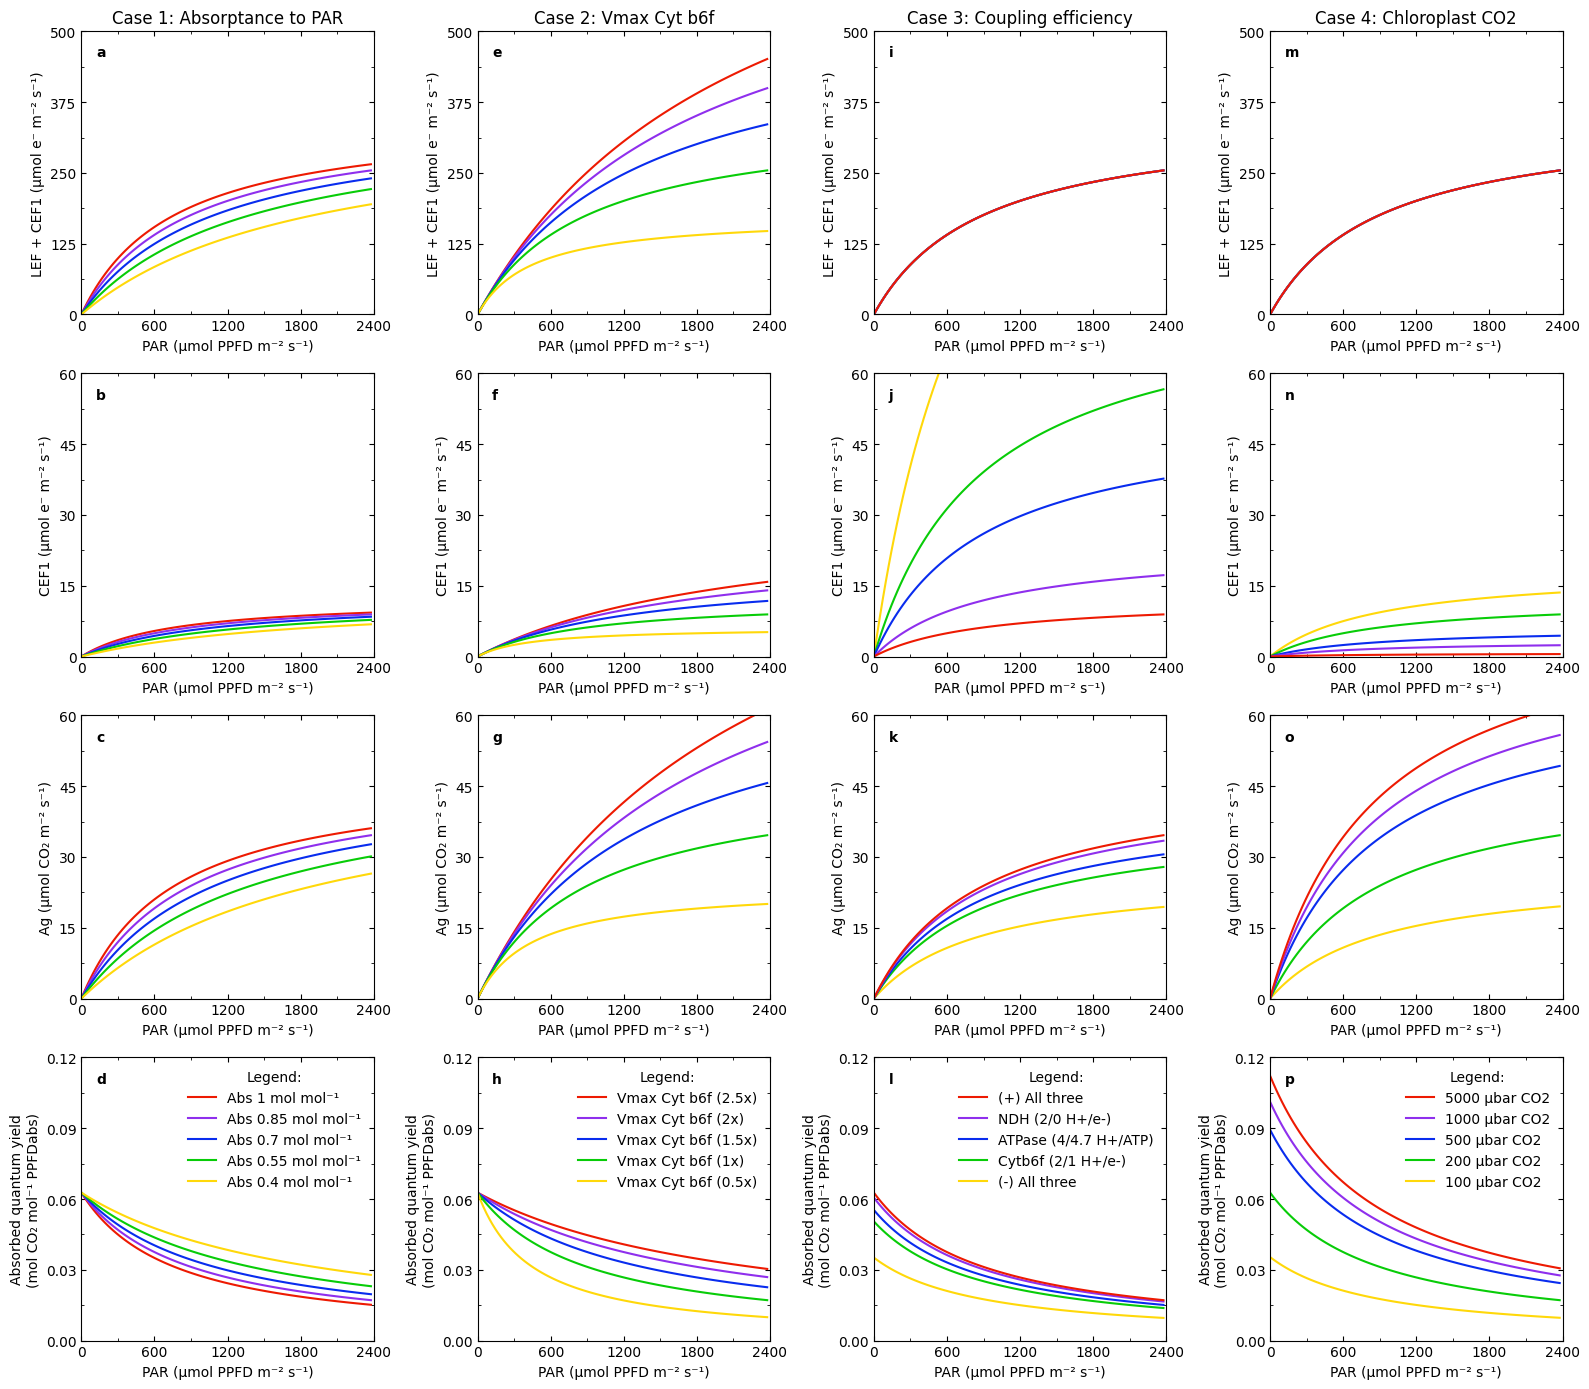

In [2]:
Q = np.arange(1, 2401, 24)

fig, axs = plt.subplots(
    4, 4,
    figsize=(16, 14),
)

colors = {
    "1": {
        1: "#ed1a02",
        0.85: "#8f2fed",
        0.7: "#092cee",
        0.55: "#08cc08",
        0.4: "#ffd80a"
    },
    "2": {
        2.5: "#ed1a02",
        2: "#8f2fed",
        1.5: "#092cee",
        1: "#08cc08",
        0.5: "#ffd80a"
    },
    "3": {
        "(+) All three": "#ed1a02",
        "NDH (2/0 H+/e-)": "#8f2fed",
        "ATPase (4/4.7 H+/ATP)": "#092cee",
        "Cytb6f (2/1 H+/e-)": "#08cc08",
        "(-) All three": "#ffd80a"
    },
    "4": {
        5000: "#ed1a02",
        1000: "#8f2fed",
        500: "#092cee",
        200: "#08cc08",
        100: "#ffd80a"
    }
}

# Case 1
for paramval in [1, 0.85, 0.7, 0.55, 0.4]:
    res = get_johnson2021(PAR=Q, Abs=paramval)
    
    axs[0, 0].plot(Q, res["JP700_j"] * 1e6, color=colors["1"][paramval])
    axs[1, 0].plot(Q, (res["JP700_j"] - res["JP680_j"]) * 1e6, color=colors["1"][paramval])
    axs[2, 0].plot(Q, res["Ag_j"] * 1e6, color=colors["1"][paramval])
    axs[3, 0].plot(Q, res["Ag_j"] / (res["Q"] * res["Abs"]), color=colors["1"][paramval])
    
# Case 2
for factor in [2.5, 2, 1.5, 1, 0.5]:
    res = get_johnson2021(PAR=Q, CB6F=(350*factor)/300/1e6)
    
    axs[0, 1].plot(Q, res["JP700_j"] * 1e6, color=colors["2"][factor])
    axs[1, 1].plot(Q, (res["JP700_j"] - res["JP680_j"]) * 1e6, color=colors["2"][factor])
    axs[2, 1].plot(Q, res["Ag_j"] * 1e6, color=colors["2"][factor])
    axs[3, 1].plot(Q, res["Ag_j"] / (res["Q"] * res["Abs"]), color=colors["2"][factor])
    
# Case 3
for key, vals in {
    "(-) All three": {
        "cytb6f": 1,
        "ndh": 0,
        "atpase": 4.7
    },
    "Cytb6f (2/1 H+/e-)": {
        "cytb6f": 1,
        "ndh": 2,
        "atpase": 4
    },
    "ATPase (4/4.7 H+/ATP)": {
        "cytb6f": 2,
        "ndh": 2,
        "atpase": 4.7
    },
    "NDH (2/0 H+/e-)": {
        "cytb6f": 2,
        "ndh": 0,
        "atpase": 4
    },
    "(+) All three": {
        "cytb6f": 2,
        "ndh": 2,
        "atpase": 4
    },
}.items():
    res = get_johnson2021(PAR=Q, nl=(1 + vals["cytb6f"]) / vals["atpase"], nc=(vals["ndh"] + 2) / vals["atpase"])
    
    axs[0, 2].plot(Q, res["JP700_j"] * 1e6, color=colors["3"][key])
    axs[1, 2].plot(Q, (res["JP700_j"] - res["JP680_j"]) * 1e6, color=colors["3"][key])
    axs[2, 2].plot(Q, res["Ag_j"] * 1e6, color=colors["3"][key])
    axs[3, 2].plot(Q, res["Ag_j"] / (res["Q"] * res["Abs"]), color=colors["3"][key])
    
# Case 4
for paramval in [100, 200, 500, 1000, 5000]:
    res = get_johnson2021(PAR=Q, CO2=paramval)
    
    axs[0, 3].plot(Q, res["JP700_j"] * 1e6, color=colors["4"][paramval])
    axs[1, 3].plot(Q, (res["JP700_j"] - res["JP680_j"]) * 1e6, color=colors["4"][paramval])
    axs[2, 3].plot(Q, res["Ag_j"] * 1e6, color=colors["4"][paramval])
    axs[3, 3].plot(Q, res["Ag_j"] / (res["Q"] * res["Abs"]), color=colors["4"][paramval])
    
# All axes
for i, ax in enumerate(axs.T.flat):
    ax.set_xlabel("PAR (µmol PPFD m⁻² s⁻¹)")
    ax.set_xlim(0, 2400)
    ax.set_xticks([0, 600, 1200, 1800, 2400])
    ax.minorticks_on()
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.text(0.05, 0.95, string.ascii_lowercase[i], transform=ax.transAxes, fontsize=10, verticalalignment='top', fontweight="bold")
    
# Per Row
for col in range(len(axs[0])):
    axs[0, col].set_ylabel("LEF + CEF1 (µmol e⁻ m⁻² s⁻¹)")
    axs[0, col].set_ylim(0, 500)
    axs[0, col].set_yticks(np.linspace(0, 500, 5))
    
    axs[1, col].set_ylabel("CEF1 (µmol e⁻ m⁻² s⁻¹)")
    axs[1, col].set_ylim(0, 60)
    axs[1, col].set_yticks(np.linspace(0, 60, 5))
    
    axs[2, col].set_ylabel("Ag (µmol CO₂ m⁻² s⁻¹)")
    axs[2, col].set_ylim(0, 60)
    axs[2, col].set_yticks(np.linspace(0, 60, 5))
    
    axs[3, col].set_ylabel("Absorbed quantum yield\n(mol CO₂ mol⁻¹ PPFDabs)")
    axs[3, col].set_ylim(0, 0.12)
    axs[3, col].set_yticks(np.linspace(0, 0.12, 5))
    
# Titles
axs[0, 0].set_title("Case 1: Absorptance to PAR")
axs[0, 1].set_title("Case 2: Vmax Cyt b6f")
axs[0, 2].set_title("Case 3: Coupling efficiency")
axs[0, 3].set_title("Case 4: Chloroplast CO2")

# Legends
for ax, color_key in zip(axs[-1], colors.keys()):
    if color_key == "1":
        txt_msg = "Abs {} mol mol⁻¹"
    elif color_key == "2":
        txt_msg = "Vmax Cyt b6f ({}x)"
    elif color_key == "3":
        txt_msg = "{}"
    else:
        txt_msg = "{} µbar CO2"
    
    color_dict = colors[color_key]
    custom_lines = [Line2D([0], [0], color=c) for c in color_dict.values()]
    custom_labels = [txt_msg.format(k) for k in color_dict.keys()]
    ax.legend(custom_lines, custom_labels, title="Legend:", frameon=False, fontsize=10)

plt.tight_layout()

## Figure 7

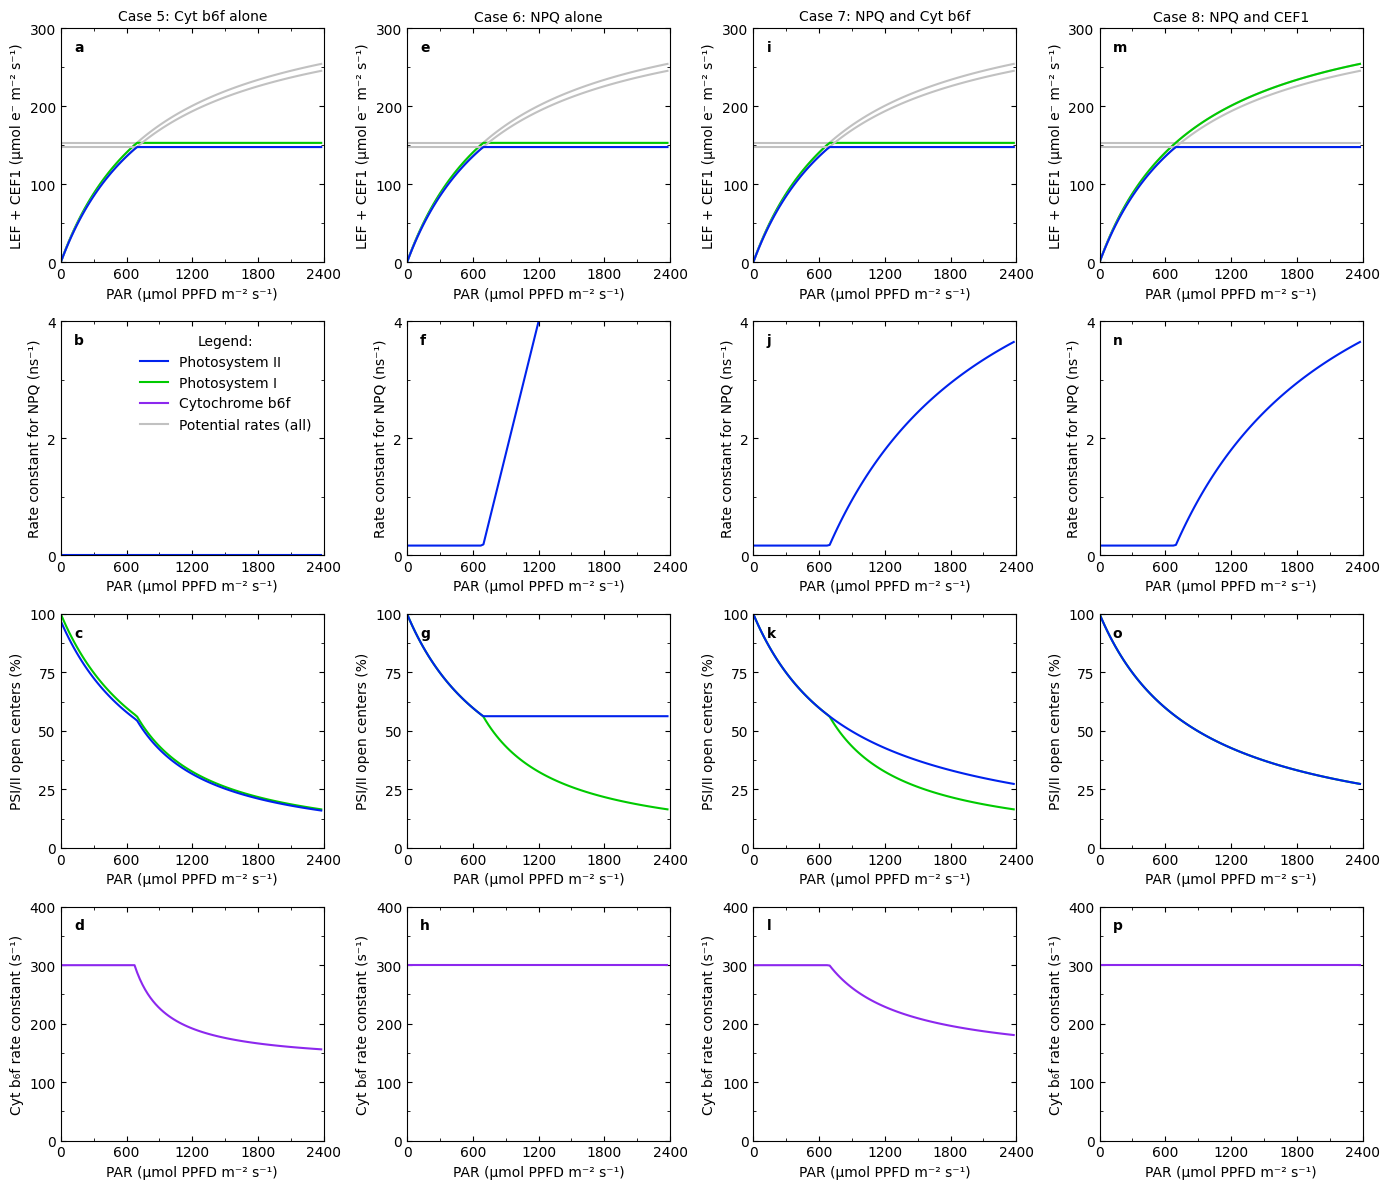

In [4]:
Q = np.arange(1, 2401, 24)

fig, axs = plt.subplots(
    4, 4,
    figsize=(14, 12),
)

case_titles = ["Case 5: Cyt b6f alone", "Case 6: NPQ alone", "Case 7: NPQ and Cyt b6f", "Case 8: NPQ and CEF1"]

colors = {
    "potential": "#c1c1c1",
    "psII": "#0022ed",
    "psI": "#00ca00",
    "cytb6f": "#8c28ee"
}

for col, case_id in enumerate([5,6,7,8]):
    res = get_johnson2021(PAR=Q, case_id=case_id, Ku2=0e09, alpha_opt="static")

    # Row 1: LEF + CEF1
    axs[0, col].plot(Q, res["JP700_j"]*1e6, color=colors["potential"], label="potential")
    axs[0, col].plot(Q, res["JP700_c"]*1e6, color=colors["potential"], label="potential")
    axs[0, col].plot(Q, res["JP700_a"]*1e6, color=colors["psI"], label="actual")
    axs[0, col].plot(Q, res["JP680_j"]*1e6, color=colors["potential"], label="potential")
    axs[0, col].plot(Q, res["JP680_c"]*1e6, color=colors["potential"], label="potential")
    axs[0, col].plot(Q, res["JP680_a"]*1e6, color=colors["psII"], label="actual")
    # Row 2: NPQ rate constant
    axs[1, col].plot(Q, res["Kn2_a"]*1e-9, color=colors["psII"], label="actual")

    # Row 3: PSI/PSII open centers
    axs[2, col].plot(Q, 100*res["q1_a"], color=colors["psI"], label="PSI")
    axs[2, col].plot(Q, 100*res["q2_a"], color=colors["psII"], label="PSII")

    # Row 4: Cyt b6f rate constant
    axs[3, col].plot(Q, res["k_CB6F"], color=colors["cytb6f"], label="potential")

    # Column titles
    axs[0, col].set_title(case_titles[col], fontsize=10)

# Apply y-limits and ticks to match Fig. 7
for col in range(4):
    # Row 1 – LEF + CEF1
    axs[0, col].set_ylabel("LEF + CEF1 (µmol e⁻ m⁻² s⁻¹)")
    axs[0, col].set_ylim(0, 300)
    axs[0, col].set_yticks([0, 100, 200, 300])

    # Row 2 – NPQ rate constant
    axs[1, col].set_ylabel("Rate constant for NPQ (ns⁻¹)")
    axs[1, col].set_ylim(0, 4)
    axs[1, col].set_yticks([0, 2, 4])

    # Row 3 – PS I / II open centers
    axs[2, col].set_ylabel("PSI/II open centers (%)")
    axs[2, col].set_ylim(0, 100)
    axs[2, col].set_yticks([0, 25, 50, 75, 100])

    # Row 4 – Cyt b6f rate constant
    axs[3, col].set_ylabel("Cyt b₆f rate constant (s⁻¹)")
    axs[3, col].set_ylim(0, 400)
    axs[3, col].set_yticks([0, 100, 200, 300, 400])

# All axes
for i, ax in enumerate(axs.T.flat):
    ax.set_xlabel("PAR (µmol PPFD m⁻² s⁻¹)")
    ax.set_xlim(0, 2400)
    ax.set_xticks([0, 600, 1200, 1800, 2400])
    ax.minorticks_on()
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.text(0.05, 0.95, string.ascii_lowercase[i], transform=ax.transAxes, fontsize=10, verticalalignment='top', fontweight="bold")
    
# Legend
custom_lines = [
    Line2D([0], [0], color=colors["psII"]),
    Line2D([0], [0], color=colors["psI"]),
    Line2D([0], [0], color=colors["cytb6f"]),
    Line2D([0], [0], color=colors["potential"])
]

# 2. Define the text labels for each line
custom_labels = [
    'Photosystem II', 
    'Photosystem I', 
    'Cytochrome b6f', 
    'Potential rates (all)'
]

# 3. Add the legend to the plot
axs[1, 0].legend(custom_lines, custom_labels, title="Legend:", frameon=False)
    
plt.tight_layout()

## Figure 8

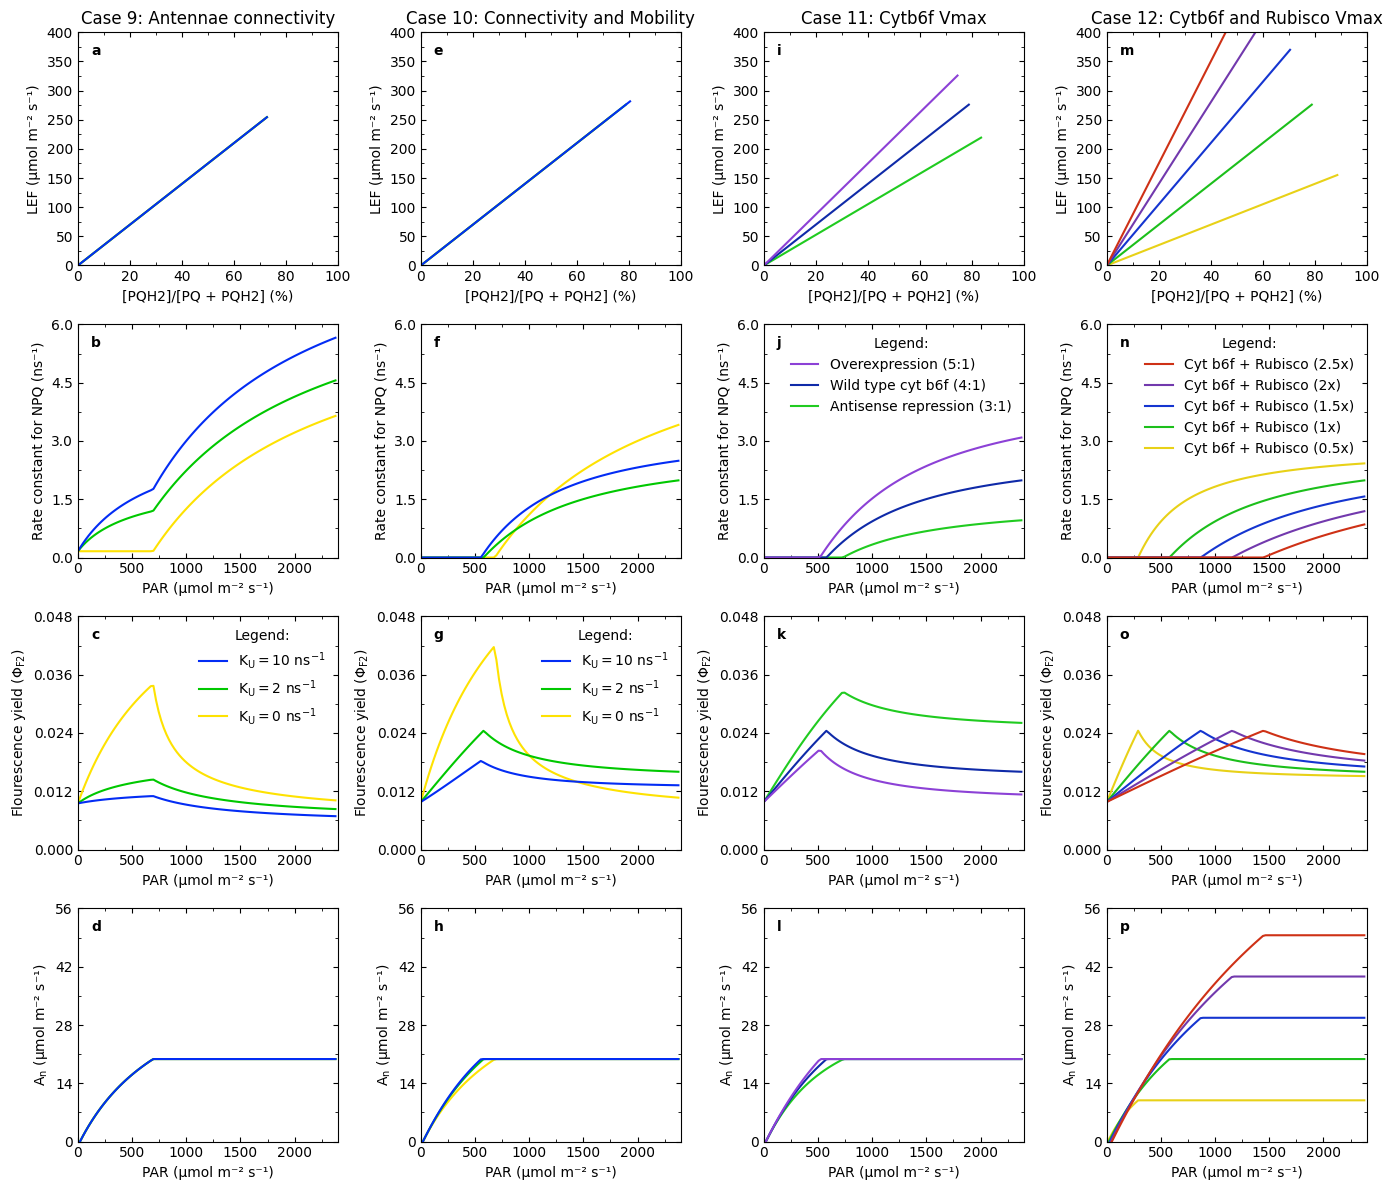

In [5]:
Q = np.arange(1, 2401, 24)

fig, axs = plt.subplots(
    4, 4,
    figsize=(14, 12),
    sharex=False
)

data = {
        'Qin': np.linspace(1, 2400, 200) * 1e6,  # 1 to 2400 PAR
        'Tin': 25.0,
        'Cin': 400.0 * 1e6,
        'Oin': 210.0 * 1e3
    }

colors = {
    "9 and 10": {
        10: "#032cf4",
        2: "#00c800",
        0: "#fee201"
    },
    "11": {
        3: "#20cb20",
        4: "#0f2aa8",
        5: "#8c41d6"
    },
    "12": {
        0.5: "#e8d117",
        1: "#1cbf1b",
        1.5: "#1535d0",
        2: "#7239ad",
        2.5: "#ce3116"
    }
}

# Case 9
for paramval in [0, 2, 10]:
    res = get_johnson2021(PAR=Q, alpha_opt="static", Ku2=paramval*1e9)
    
    axs[0, 0].plot((1 - res['q2_a']) * 100, res["JP700_j"] * 1e6, color=colors["9 and 10"][paramval], label="actual")
    axs[1, 0].plot(res["PAR"], res["Kn2_a"]*1e-9, color=colors["9 and 10"][paramval], label="actual")
    axs[2, 0].plot(res["PAR"], res["phi2F_a"], color=colors["9 and 10"][paramval], label="actual")
    axs[3, 0].plot(res["PAR"], res["An_a"]*1e6 , color=colors["9 and 10"][paramval], label="actual")
    
# Case 10
for paramval in [0, 2, 10]:
    res = get_johnson2021(PAR=Q, alpha_opt="dynamic", Ku2=paramval*1e9)
    
    axs[0, 1].plot((1 - res['q2_a']) * 100, res["JP700_j"] * 1e6, color=colors["9 and 10"][paramval], label="actual")
    axs[1, 1].plot(res["PAR"], res["Kn2_a"]*1e-9, color=colors["9 and 10"][paramval], label="actual")
    axs[2, 1].plot(res["PAR"], res["phi2F_a"], color=colors["9 and 10"][paramval], label="actual")
    axs[3, 1].plot(res["PAR"], res["An_a"]*1e6, color=colors["9 and 10"][paramval], label="actual")

# Case 11
for factor in [3, 4, 5]:
    res = get_johnson2021(PAR=Q, alpha_opt="dynamic", Ku2=2e9, CB6F=(350 / 300) * factor / 4 / 1e6)
    
    axs[0, 2].plot((1 - res['q2_a']) * 100, res["JP700_j"] * 1e6, color=colors["11"][factor], label="actual")
    axs[1, 2].plot(res["PAR"], res["Kn2_a"]*1e-9, color=colors["11"][factor], label="actual")
    axs[2, 2].plot(res["PAR"], res["phi2F_a"], color=colors["11"][factor], label="actual")
    axs[3, 2].plot(res["PAR"], res["An_a"]*1e6, color=colors["11"][factor], label="actual")

# Case 12
for factor in [0.5, 1, 1.5, 2, 2.5]:
    res = get_johnson2021(PAR=Q, alpha_opt="dynamic", Ku2=2e9, CB6F=(350 / 300) * factor / 1e6, RUB=(100 / 3.6) * factor / 1e6,)
    
    axs[0, 3].plot((1 - res['q2_a']) * 100, res["JP700_j"] * 1e6, color=colors["12"][factor], label="actual")
    axs[1, 3].plot(Q, res["Kn2_a"]*1e-9, color=colors["12"][factor], label="actual")
    axs[2, 3].plot(Q, res["phi2F_a"], color=colors["12"][factor], label="actual")
    axs[3, 3].plot(Q, res["An_a"]*1e6, color=colors["12"][factor], label="actual")

# x-labels
for i, ax in enumerate(axs.T.flat):
    ax.minorticks_on()
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.text(0.05, 0.95, string.ascii_lowercase[i], transform=ax.transAxes, fontsize=10, verticalalignment='top', fontweight="bold")

for axcol in range(len(axs)):
    axs[0, axcol].set_xlabel("[PQH2]/[PQ + PQH2] (%)")
    axs[0, axcol].set_xlim(0, 100)
    axs[0, axcol].set_ylabel("LEF (μmol m⁻² s⁻¹)")
    axs[0, axcol].set_ylim(0, 400)
    
    for axrow in range(1, len(axs[0])):
        axs[axrow, axcol].set_xlabel("PAR (μmol m⁻² s⁻¹)")
        axs[axrow, axcol].set_xlim(0, 2400)
        
    axs[1, axcol].set_ylabel("Rate constant for NPQ (ns⁻¹)")
    axs[1, axcol].set_ylim(0, 6)
    axs[1, axcol].set_yticks(np.linspace(0, 6, 5))
    
    axs[2, axcol].set_ylabel(r"Flourescence yield ($\Phi _{\mathrm{F2}}$)")
    axs[2, axcol].set_ylim(0, 0.048)
    axs[2, axcol].set_yticks(np.linspace(0, 0.048, 5))
    
    axs[3, axcol].set_ylabel(r"A$_\mathrm{n}$ (μmol m⁻² s⁻¹)")
    axs[3, axcol].set_ylim(0, 56)
    axs[3, axcol].set_yticks(np.linspace(0, 56, 5))
    
axs[0, 0].set_title("Case 9: Antennae connectivity")
axs[0, 1].set_title("Case 10: Connectivity and Mobility")
axs[0, 2].set_title("Case 11: Cytb6f Vmax")
axs[0, 3].set_title("Case 12: Cytb6f and Rubisco Vmax")

# Legends
for col in [0, 1]:
    custom_lines = [
        Line2D([0], [0], color=colors["9 and 10"][10]),
        Line2D([0], [0], color=colors["9 and 10"][2]),
        Line2D([0], [0], color=colors["9 and 10"][0]),
    ]

    custom_labels = [
        r"$\mathrm{K_U = 10\ ns^{-1}}$", 
        r"$\mathrm{K_U = 2\ ns^{-1}}$",
        r"$\mathrm{K_U = 0\ ns^{-1}}$",
    ]

    axs[2, col].legend(custom_lines, custom_labels, title="Legend:", frameon=False)
    
custom_lines = [
    Line2D([0], [0], color=colors["11"][5]),
    Line2D([0], [0], color=colors["11"][4]),
    Line2D([0], [0], color=colors["11"][3]),
]

custom_labels = [
    "Overexpression (5:1)", 
    "Wild type cyt b6f (4:1)",
    "Antisense repression (3:1)",
]

axs[1, 2].legend(custom_lines, custom_labels, title="Legend:", frameon=False)

custom_lines = [Line2D([0], [0], color=colors["12"][i]) for i in [2.5, 2, 1.5, 1, 0.5]]

custom_labels = [f"Cyt b6f + Rubisco ({i}x)" for i in [2.5, 2, 1.5, 1, 0.5]]

axs[1, 3].legend(custom_lines, custom_labels, title="Legend:", frameon=False)

plt.tight_layout()